In [ ]:
#Installing kaggle library
#Uploading kaggle.json file (token to connect to kaggle)
!pip install kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tanjaldir","key":"cb91ac02c819a45f54ad9446b7b44eb7"}'}

In [ ]:
#Moving kaggle.json file to correct location
#Setting appropriate permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Downloading dataset
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database -p /content/covid19_radiography

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:40<00:00, 25.6MB/s]
100% 778M/778M [00:40<00:00, 20.0MB/s]


In [ ]:
#Unzipping dataset
!unzip /content/covid19_radiography/covid19-radiography-database.zip -d /content/covid19_radiography

Streaming output truncated to the last 5000 lines.
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: /content/covid19_radiography/COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: /content/covid19_r

In [ ]:
pip install zarr

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.2/210.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 78.9 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5033 sha256=40d60695251222cf794d580f0a219f68af0bd858fe041c8bc9ab94f975eb94eb
  Stored in directory: /root/.cache/pip/wheels/7f/4e/be/1171b40f43b918087657ec57cf3b81fa1a2e027d8755baa184
Successfully built asciitree


In [ ]:
#Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import gc
import sys
import psutil
import tables
import dask.dataframe as dd
import zarr
from collections import Counter
import requests

In [ ]:
#Setting folder path
folder_path = "/content/covid19_radiography/COVID-19_Radiography_Dataset"

In [ ]:
#Setting subfolder paths
subfolder_paths = ["COVID/images", 'Lung_Opacity/images', "Normal/images", "Viral Pneumonia/images"]

In [ ]:
#Function to convert to graysscale
def convert_to_greyscale(img):
  grey_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  return grey_img

In [ ]:
#Function to resize images
def resize_image(img, size):
  resized_img = cv2.resize(img, size)
  return resized_img

In [ ]:
#Function to apply mask
def apply_mask(img, msk):
    msk_resized = cv2.resize(msk, dsize = (299,299), interpolation = cv2.INTER_LINEAR)
    img_float = img.astype(np.float32)
    msk_img = cv2.bitwise_and(img_float, img_float, mask=msk_resized)
    msk_img[msk_resized == 0] = 0
    #Exclude the black pixels
    return msk_img

In [ ]:
#Function to normalize pixel values
def normalize_pixel(img):
  img = np.asarray(img)
  mini = np.nanmin(img)
  maxi = np.nanmax(img)
  if maxi > mini:
      normalized_img = (img - mini) / (maxi - mini)
  else:
      normalized_img = np.zeros_like(img)
  return normalized_img

In [ ]:
#Function to retrieve pixel values
def get_1d_array(img):
  img_flattened = img.flatten()
  return img_flattened

In [ ]:
#Function to track memory
def log_memory_usage():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    #Converting bytes to megabytes
    print(f'Memory usage: {mem_info.rss / (1024 ** 2):.2f} MB')

In [ ]:
#Function to estimate memory usage to eventually estimate batch size
def estimate_memory_usage(img_path):
    #Reading image
    image = cv2.imread(img_path)
    #Converting to grayscale
    grey_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    #Normalizing
    norm_img = grey_img / 255.0
    #Retrieving one-d-array
    one_d_array = norm_img.flatten()

    #Determining memory usage
    image_size = sys.getsizeof(image)
    grey_img_size = sys.getsizeof(grey_img)
    norm_img_size = sys.getsizeof(norm_img)
    one_d_array_size = sys.getsizeof(one_d_array)

    return image_size + grey_img_size + norm_img_size + one_d_array_size

In [ ]:
#Function to pipe through images, applying preprocessing operations
def process_batch(img_paths):

  batch_pixel_values = []
  batch_case_names = []

  for img_path in img_paths:
      msk_path = img_path.replace('/images/', '/masks/')
      img_string = os.path.splitext(os.path.basename(img_path))[0]
      image = cv2.imread(img_path)
      msk = cv2.imread(msk_path)
      grey_img = convert_to_greyscale(image)
      grey_msk = convert_to_greyscale(msk)
      msk_img = apply_mask(grey_img, grey_msk)
      one_d_array = get_1d_array(msk_img)

      batch_pixel_values.append(one_d_array)
      batch_case_names.append(img_string.split('-')[0])

      del image, grey_img, msk_img, one_d_array
      gc.collect()

  batch_pixel_values = np.array(batch_pixel_values, dtype=np.float32)
  return batch_pixel_values, batch_case_names

In [ ]:
#Checking estimated memory usage for one image
img_path = '/content/covid19_radiography/COVID-19_Radiography_Dataset/COVID/images/COVID-1.png'
memory_per_image = estimate_memory_usage(img_path)
#Converting from bytes to megabytes
memory_per_image = memory_per_image / (1024 ** 2)
print(f"{memory_per_image} MB")

In [ ]:
#Estimating batch size
#Converting GB to MB
free_memory_mb = 11.41 * 1024
#Calculating batch size theoretically
batch_size = free_memory_mb / memory_per_image
print(batch_size)

6849.972050732109


In [ ]:
#Setting batch size
batch_size = 50
index = 0

In [ ]:
#Setting empty lists for pixel values, names and cases
pixel_values = np.empty((0, 299 * 299), dtype=np.float32)
case_names = []
index = 0
pixel_values.shape

(0, 89401)

In [ ]:
#Piping through images in batches
for subfolder in subfolder_paths:
    subfolder_path = os.path.join(folder_path, subfolder)
    subfolder_path_mask = f"{folder_path}/{subfolder.split('/')[0]}/masks"
    image_files = os.listdir(subfolder_path)

    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i + batch_size]
        batch_paths = [os.path.join(subfolder_path, img) for img in batch_files]
        batch_pixel_values, batch_case_names = process_batch(batch_paths)

        #Extending the main lists with batch data
        pixel_values = np.vstack([pixel_values, batch_pixel_values])
        case_names.extend(batch_case_names)

        log_memory_usage()
        index +=1
        print(index)

        #Freeing memory after processing each batch
        del batch_pixel_values, batch_case_names
        gc.collect()

Memory usage: 401.96 MB
1
Memory usage: 453.76 MB
2
Memory usage: 487.88 MB
3
Memory usage: 521.94 MB
4
Memory usage: 555.93 MB
5
Memory usage: 590.18 MB
6
Memory usage: 624.36 MB
7
Memory usage: 658.23 MB
8
Memory usage: 692.48 MB
9
Memory usage: 726.68 MB
10
Memory usage: 760.77 MB
11
Memory usage: 794.83 MB
12
Memory usage: 829.00 MB
13
Memory usage: 863.32 MB
14
Memory usage: 897.38 MB
15
Memory usage: 931.57 MB
16
Memory usage: 965.52 MB
17
Memory usage: 999.71 MB
18
Memory usage: 1033.88 MB
19
Memory usage: 1067.98 MB
20
Memory usage: 1102.01 MB
21
Memory usage: 1136.20 MB
22
Memory usage: 1170.17 MB
23
Memory usage: 1204.29 MB
24
Memory usage: 1238.51 MB
25
Memory usage: 1272.45 MB
26
Memory usage: 1306.54 MB
27
Memory usage: 1340.83 MB
28
Memory usage: 1374.82 MB
29
Memory usage: 1409.01 MB
30
Memory usage: 1443.41 MB
31
Memory usage: 1477.49 MB
32
Memory usage: 1511.56 MB
33
Memory usage: 1545.73 MB
34
Memory usage: 1579.80 MB
35
Memory usage: 1613.68 MB
36
Memory usage: 1648.

In [ ]:
#Checking length of lists
print(len(pixel_values))
print(len(case_names))

21165
21165


In [ ]:
#Checking first 1d array in list
print(len(pixel_values[0]))

89401


In [ ]:
#Checking type and shape
print(type(pixel_values), pixel_values.shape)

<class 'numpy.ndarray'> (21165, 89401)


In [ ]:
#Dropping duplicates
rounded_pixel_values = np.round(pixel_values, decimals=6)
_, unique_indices = np.unique(rounded_pixel_values, axis=0, return_index=True)
pixel_values = pixel_values[sorted(unique_indices)]
case_names = [case_names[i] for i in sorted(unique_indices)]

In [ ]:
#Checking shape
print(pixel_values.shape)
print(len(case_names))

(21105, 89401)
21105


In [ ]:
#Converting numpy to memmap
pixel_values.tofile('data.bin')
mmap_arr = np.memmap('data.bin', dtype = pixel_values.dtype, mode = 'r+', shape = pixel_values.shape)

In [ ]:
#Saving array on GoogleDrive

zarr_array = zarr.open("/content/drive/My Drive/Team Project X-Rays/Dataframes/data_2.0.zarr", mode='w', shape = mmap_arr.shape, dtype = 'float32', compressor = zarr.Blosc(cname='zstd', clevel=3, shuffle=2))

zarr_array[:] = mmap_arr

In [ ]:
#Converting target into categorical
target_mapping = {'Normal': 0, 'COVID': 1, 'Lung_Opacity': 2, 'Viral Pneumonia': 3}

In [ ]:
target_improved = [target_mapping[case] for case in case_names]

In [ ]:
#Counting the frequency of each class
class_counts = Counter(target_improved)

#Calculating total number of samples
total_samples = len(target_improved)

#Calculating the proportion of each class
class_proportions = {cls: count / total_samples for cls, count in class_counts.items()}

print("Class Proportions:", class_proportions)

Class Proportions: {1: 0.16886993603411513, 2: 0.28486140724946696, 0: 0.4828713574982232, 3: 0.06339729921819474}


In [ ]:
#Converting to array
target = np.array(target_improved)

In [ ]:
#Converting numpy to memmap
target.tofile('data_target.bin')
mmap_arr = np.memmap('data_target.bin', dtype = target.dtype, mode = 'r+', shape = target.shape)

In [ ]:
#Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zarr_array = zarr.open("/content/drive/My Drive/Team Project X-Rays/Dataframes/target_2.0.zarr", mode='w', shape=mmap_arr.shape, dtype='float32', compressor=zarr.Blosc(cname='zstd', clevel=3, shuffle=2))
zarr_array[:] = mmap_arr

In [ ]:
zarr_array2 = zarr.open("D:/data_2.0.zarr", mode='r')

In [ ]:
#Checking shape
zarr_array2.shape

(21105, 89401)

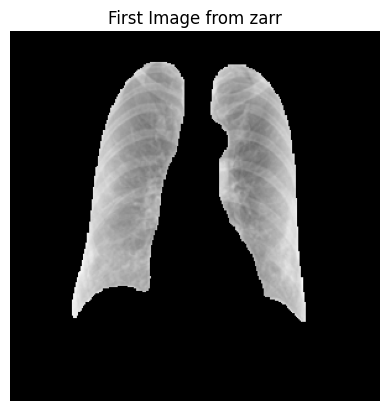

In [ ]:
#Checking by displaying image
image_1d = zarr_array2[5]
image_2d = image_1d.reshape((299, 299))

plt.imshow(image_2d, cmap='gray')
plt.title('First Image from zarr')
plt.axis('off')
plt.show()